# Notebook 02 — Data Preparation

This notebook prepares the DeepFashion-MultiModal dataset for training.
Dataset: https://github.com/yumingj/DeepFashion-MultiModal

Steps:
1. Ensure the dataset is uploaded to Kaggle and paths are correct.
2. Run all cells in order.
3. Collect the output files from `/kaggle/working`: `train.csv`, `val.csv`, `test.csv`, `class_weights.pt`.

# 1 - Imports and reproducibility seed

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

from sklearn.model_selection import train_test_split

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


# 2 - Path configuration (Kaggle layout)

In [3]:
BASE_DIR = Path('/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal')

IMAGES_DIR   = Path('/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/images/images')
SEGM_DIR     = Path('/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/segm/segm')
SHAPE_FILE   = Path('/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/labels/labels/shape/shape_anno_all.txt')
FABRIC_FILE  = Path('/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/labels/labels/texture/fabric_ann.txt')
PATTERN_FILE = Path('/kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/labels/labels/texture/pattern_ann.txt')

# Output directory (writable on Kaggle)
OUTPUT_DIR = Path('/kaggle/working')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Quick sanity-check
for p in [IMAGES_DIR, SEGM_DIR, SHAPE_FILE, FABRIC_FILE, PATTERN_FILE]:
    status = "✅" if p.exists() else "❌  NOT FOUND"
    print(f"{status}  {p}")

✅  /kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/images/images
✅  /kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/segm/segm
✅  /kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/labels/labels/shape/shape_anno_all.txt
✅  /kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/labels/labels/texture/fabric_ann.txt
✅  /kaggle/input/datasets/miguelmirandar/deepfashion-multimodal/labels/labels/texture/pattern_ann.txt


# 3 — Class mappings and NA sentinels

In [4]:
# These match the values documented in the DeepFashion-MultiModal repo.

SLEEVE_MAP  = {0:'sleeveless', 1:'short', 2:'medium', 3:'long', 4:'not long-sleeve', 5:'NA'}
LOWER_MAP   = {0:'three-point', 1:'medium short', 2:'three-quarter', 3:'long', 4:'NA'}
NECKLINE_MAP= {0:'V-shape', 1:'square', 2:'round', 3:'standing', 4:'lapel', 5:'suspenders', 6:'NA'}
FABRIC_MAP  = {0:'denim', 1:'cotton', 2:'leather', 3:'furry', 4:'knitted', 5:'chiffon', 6:'other', 7:'NA'}
PATTERN_MAP = {0:'floral', 1:'graphic', 2:'striped', 3:'pure color', 4:'lattice', 5:'other', 6:'color block', 7:'NA'}

# Integer codes that represent "not annotated / not applicable"
NA_VALUES = {
    'sleeve_length': 5,
    'lower_length':  4,
    'neckline':      6,
    'upper_fabric':  7,
    'upper_color':   7,   # pattern column is used as upper_color proxy
}

# Phase-1 target columns and their number of valid classes (NA excluded)
PHASE1_TARGETS = {
    'sleeve_length': 5,   # classes 0-4
    'upper_fabric':  7,   # classes 0-6
    'upper_color':   7,   # classes 0-6 (pattern column)
}

print("Class mappings loaded.")

Class mappings loaded.


# 4 — Load and merge annotation files

In [7]:
# ── Shape annotations ────────────────────────────────────────────────────────
df_shape = pd.read_csv(
    SHAPE_FILE, sep=' ', header=None,
    usecols=[0, 1, 2, 3],
    names=['image_name', 'sleeve_length', 'lower_length', 'neckline'],
    dtype={'image_name': str, 'sleeve_length': np.int8,
           'lower_length': np.int8, 'neckline': np.int8}
)

# ── Fabric (upper_fabric) ─────────────────────────────────────────────────────
df_fabric = pd.read_csv(
    FABRIC_FILE, sep=' ', header=None,
    usecols=[0, 1],
    names=['image_name', 'upper_fabric'],
    dtype={'image_name': str, 'upper_fabric': np.int8}
)

# ── Pattern / color (upper_color) ────────────────────────────────────────────
df_pattern = pd.read_csv(
    PATTERN_FILE, sep=' ', header=None,
    usecols=[0, 1],
    names=['image_name', 'upper_color'],
    dtype={'image_name': str, 'upper_color': np.int8}
)

# ── Merge on image_name ───────────────────────────────────────────────────────
df = df_shape.merge(df_fabric,  on='image_name', how='left') \
             .merge(df_pattern, on='image_name', how='left')

print(f"Merged DataFrame: {df.shape[0]:,} rows × {df.shape[1]} cols")
df.head(3)

Merged DataFrame: 42,544 rows × 6 cols


,image_name,sleeve_length,lower_length,neckline,upper_fabric,upper_color
0,MEN-Denim-id_00000080-01_7_additional.jpg,5,3,0,1,3
1,MEN-Denim-id_00000089-01_7_additional.jpg,0,3,0,1,3
2,MEN-Denim-id_00000089-02_7_additional.jpg,3,3,0,1,2


# 5 — Filter Phase-1 attributes (drop NA rows)

In [8]:
# We drop any row where sleeve_length, upper_fabric, or upper_color
# carries its NA sentinel value.

phase1_cols = list(PHASE1_TARGETS.keys())

mask_valid = (
    (df['sleeve_length'] != NA_VALUES['sleeve_length']) &
    (df['upper_fabric']  != NA_VALUES['upper_fabric'])  &
    (df['upper_color']   != NA_VALUES['upper_color'])
)

df_phase1 = df[mask_valid][['image_name'] + phase1_cols].copy().reset_index(drop=True)

print(f"Rows before filter : {len(df):,}")
print(f"Rows after  filter : {len(df_phase1):,}")
print(f"Rows dropped       : {len(df) - len(df_phase1):,}")
df_phase1.head(3)

Rows before filter : 42,544
Rows after  filter : 41,487
Rows dropped       : 1,057


,image_name,sleeve_length,upper_fabric,upper_color
0,MEN-Denim-id_00000089-01_7_additional.jpg,0,1,3
1,MEN-Denim-id_00000089-02_7_additional.jpg,3,1,2
2,MEN-Denim-id_00000089-03_7_additional.jpg,1,1,3


# 6 — Verify image files exist on disk

In [9]:
# Removes rows whose image file is missing from IMAGES_DIR.

def image_exists(name: str) -> bool:
    return (IMAGES_DIR / name).exists()

exists_mask = df_phase1['image_name'].apply(image_exists)
n_missing   = (~exists_mask).sum()

if n_missing > 0:
    print(f"⚠️  {n_missing} images not found on disk — dropping them.")
    df_phase1 = df_phase1[exists_mask].reset_index(drop=True)
else:
    print("✅  All image files found on disk.")

print(f"Final dataset size: {len(df_phase1):,} examples")

✅  All image files found on disk.
Final dataset size: 41,487 examples


# 7 — Class distribution analysis

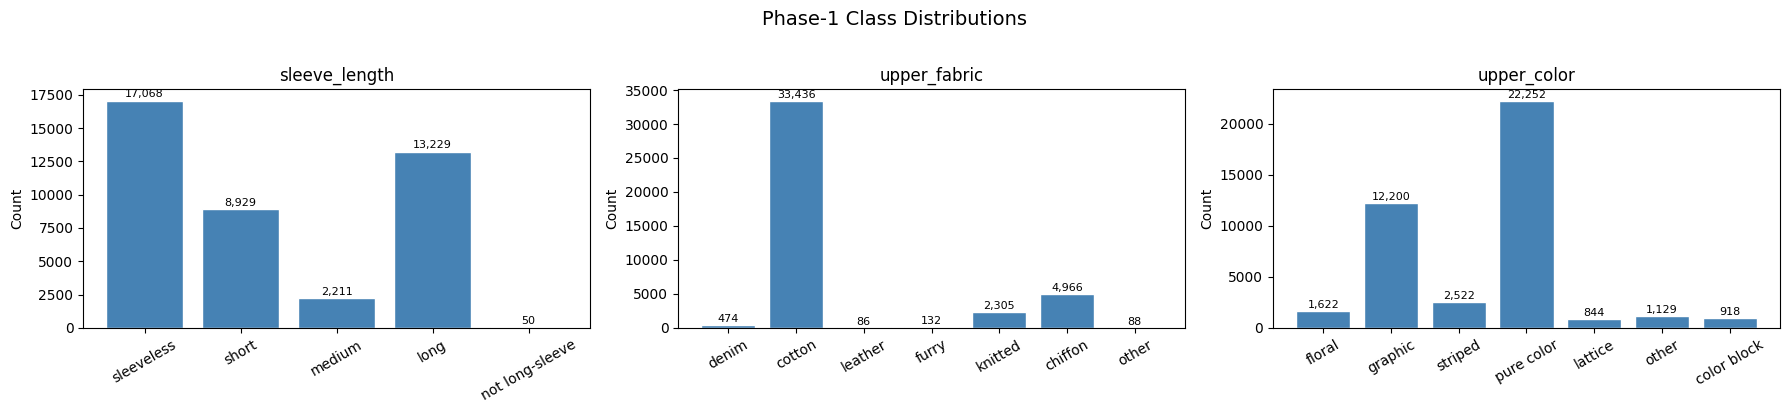

Plot saved to /kaggle/working/class_distributions.png


In [10]:
# Visualise per-attribute distributions to detect class imbalance
# before deciding on any re-weighting strategy.

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
fig.suptitle("Phase-1 Class Distributions", fontsize=14, y=1.02)

label_maps = {
    'sleeve_length': SLEEVE_MAP,
    'upper_fabric':  FABRIC_MAP,
    'upper_color':   PATTERN_MAP,
}

for ax, col in zip(axes, phase1_cols):
    counts = df_phase1[col].value_counts().sort_index()
    lmap   = label_maps[col]
    labels = [lmap.get(i, str(i)) for i in counts.index]
    ax.bar(labels, counts.values, color='steelblue', edgecolor='white')
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(ax.patches, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                f"{val:,}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "class_distributions.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved to", OUTPUT_DIR / "class_distributions.png")

# 8 — Compute per-class weights for weighted loss

In [11]:
# Inverse-frequency weights help counteract class imbalance during training.
# We compute them here and save them; the training notebook will load them.

def compute_class_weights(series: pd.Series, n_classes: int) -> torch.Tensor:
    """Return inverse-frequency weights as a float32 tensor."""
    counts = series.value_counts().sort_index()
    # Fill missing classes with count=1 to avoid division by zero
    counts = counts.reindex(range(n_classes), fill_value=1)
    weights = 1.0 / counts.values.astype(float)
    weights = weights / weights.sum() * n_classes   # normalise
    return torch.tensor(weights, dtype=torch.float32)

class_weights = {}
for col, n_cls in PHASE1_TARGETS.items():
    class_weights[col] = compute_class_weights(df_phase1[col], n_cls)
    print(f"{col:20s}  weights: {class_weights[col].numpy().round(3)}")

# Save weights so the training notebook doesn't need to recompute them
torch.save(class_weights, OUTPUT_DIR / "class_weights.pt")
print("\nClass weights saved to", OUTPUT_DIR / "class_weights.pt")

sleeve_length         weights: [0.014 0.027 0.109 0.018 4.831]
upper_fabric          weights: [0.443 0.006 2.441 1.59  0.091 0.042 2.386]
upper_color           weights: [1.004 0.133 0.646 0.073 1.929 1.442 1.773]

Class weights saved to /kaggle/working/class_weights.pt


# 9 — Train / Validation / Test split  (70 / 15 / 15)

In [13]:
# Stratified on sleeve_length (most balanced attribute) to keep
# class proportions consistent across all three splits.

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.15
TEST_RATIO  = 0.15

strat_col = 'sleeve_length'

# First: split off test set
df_trainval, df_test = train_test_split(
    df_phase1,
    test_size=TEST_RATIO,
    random_state=SEED,
    stratify=df_phase1[strat_col],
)

# Then: split remaining into train + val
val_size_adjusted = VAL_RATIO / (TRAIN_RATIO + VAL_RATIO)
df_train, df_val = train_test_split(
    df_trainval,
    test_size=val_size_adjusted,
    random_state=SEED,
    stratify=df_trainval[strat_col],
)

df_train = df_train.reset_index(drop=True)
df_val   = df_val.reset_index(drop=True)
df_test  = df_test.reset_index(drop=True)

total = len(df_phase1)
print(f"Total  : {total:>6,}  (100.0%)")
print(f"Train  : {len(df_train):>6,}  ({100*len(df_train)/total:.1f}%)")
print(f"Val    : {len(df_val):>6,}  ({100*len(df_val)/total:.1f}%)")
print(f"Test   : {len(df_test):>6,}  ({100*len(df_test)/total:.1f}%)")

Total  : 41,487  (100.0%)
Train  : 29,040  (70.0%)
Val    :  6,223  (15.0%)
Test   :  6,224  (15.0%)


# 10 — Verify stratification quality

In [14]:
# The sleeve_length distribution should be similar across all three splits.

def split_distribution(df: pd.DataFrame, col: str, lmap: dict) -> pd.Series:
    counts = df[col].value_counts(normalize=True).sort_index()
    counts.index = [lmap[i] for i in counts.index]
    return counts.rename(col)

dist = pd.concat([
    split_distribution(df_train, strat_col, SLEEVE_MAP).rename('train'),
    split_distribution(df_val,   strat_col, SLEEVE_MAP).rename('val'),
    split_distribution(df_test,  strat_col, SLEEVE_MAP).rename('test'),
], axis=1).round(3)

print("sleeve_length distribution per split (proportions):")
display(dist)

sleeve_length distribution per split (proportions):


,train,val,test
sleeveless,0.411,0.411,0.411
short,0.215,0.215,0.215
medium,0.053,0.053,0.053
long,0.319,0.319,0.319
not long-sleeve,0.001,0.001,0.001


# 11 — Save split CSVs

In [15]:
# These CSVs are the single source of truth for downstream notebooks.

df_train.to_csv(OUTPUT_DIR / "train.csv", index=False)
df_val.to_csv(  OUTPUT_DIR / "val.csv",   index=False)
df_test.to_csv( OUTPUT_DIR / "test.csv",  index=False)

print("Saved:")
for fname in ["train.csv", "val.csv", "test.csv"]:
    path = OUTPUT_DIR / fname
    print(f"  {path}  ({path.stat().st_size / 1024:.1f} KB)")

Saved:
  /kaggle/working/train.csv  (1432.4 KB)
  /kaggle/working/val.csv  (306.4 KB)
  /kaggle/working/test.csv  (307.1 KB)


# 12 — Image statistics (mean & std for normalisation)

In [16]:
# We sample a random subset of training images to compute per-channel
# mean and standard deviation used by the normalisation transform.

SAMPLE_SIZE = 2000   # increase for more accuracy; decrease if too slow
IMG_SIZE    = (224, 224)

sample_names = df_train['image_name'].sample(SAMPLE_SIZE, random_state=SEED).tolist()

pixel_sum  = np.zeros(3, dtype=np.float64)
pixel_sq   = np.zeros(3, dtype=np.float64)
pixel_count = 0

to_tensor = T.Compose([T.Resize(IMG_SIZE), T.ToTensor()])

for name in sample_names:
    img = Image.open(IMAGES_DIR / name).convert('RGB')
    t   = to_tensor(img).numpy()          # shape: (3, H, W)
    pixel_sum  += t.sum(axis=(1, 2))
    pixel_sq   += (t ** 2).sum(axis=(1, 2))
    pixel_count += t.shape[1] * t.shape[2]

mean = pixel_sum  / pixel_count
std  = np.sqrt(pixel_sq / pixel_count - mean ** 2)

print(f"Dataset mean : {mean.round(4)}")
print(f"Dataset std  : {std.round(4)}")
print()
print("(Compare with ImageNet: mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])")

Dataset mean : [0.7893 0.7595 0.7493]
Dataset std  : [0.2568 0.2731 0.2813]

(Compare with ImageNet: mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])


# 13 — Define image transforms

In [17]:
# Training uses augmentation; validation and test use only resize + normalise.
# We use ImageNet statistics because we will fine-tune from ImageNet weights.

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
IMG_SIZE      = 224

train_transforms = T.Compose([
    T.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),   # slightly larger for crop
    T.RandomCrop(IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.RandomRotation(degrees=10),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transforms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# test_transforms == val_transforms (no augmentation at inference)
test_transforms = val_transforms

print("Transforms defined.")
print("Train:", train_transforms)
print()
print("Val/Test:", val_transforms)

Transforms defined.
Train: Compose(
    Resize(size=(256, 256), interpolation=bilinear, max_size=None, antialias=True)
    RandomCrop(size=(224, 224), padding=None)
    RandomHorizontalFlip(p=0.5)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Val/Test: Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


# 14 — GarmentDataset class

In [18]:
# Custom PyTorch Dataset that loads an image and returns the three
# Phase-1 labels (sleeve_length, upper_fabric, upper_color) as a dict.

class GarmentDataset(Dataset):
    """Multi-output garment attribute dataset.

    Args:
        df         : DataFrame with columns [image_name, sleeve_length,
                     upper_fabric, upper_color].
        images_dir : Path to directory containing the image files.
        transform  : torchvision transform pipeline (train / val / test).
    """

    TARGET_COLS = ['sleeve_length', 'upper_fabric', 'upper_color']

    def __init__(self, df: pd.DataFrame, images_dir: Path,
                 transform: T.Compose = None):
        self.df         = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform  = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]

        # ── Load image ───────────────────────────────────────────────────────
        img_path = self.images_dir / row['image_name']
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        # ── Build label dict ─────────────────────────────────────────────────
        labels = {
            col: torch.tensor(int(row[col]), dtype=torch.long)
            for col in self.TARGET_COLS
        }

        return image, labels


print("GarmentDataset class defined.")

GarmentDataset class defined.


# 15 — Instantiate datasets and data loaders

In [19]:
BATCH_SIZE  = 64
NUM_WORKERS = 2   # adjust based on Kaggle CPU count

train_dataset = GarmentDataset(df_train, IMAGES_DIR, transform=train_transforms)
val_dataset   = GarmentDataset(df_val,   IMAGES_DIR, transform=val_transforms)
test_dataset  = GarmentDataset(df_test,  IMAGES_DIR, transform=test_transforms)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f"Train loader : {len(train_loader):>4} batches  ({len(train_dataset):,} samples)")
print(f"Val loader   : {len(val_loader):>4} batches  ({len(val_dataset):,} samples)")
print(f"Test loader  : {len(test_loader):>4} batches  ({len(test_dataset):,} samples)")

Train loader :  454 batches  (29,040 samples)
Val loader   :   98 batches  (6,223 samples)
Test loader  :   98 batches  (6,224 samples)


# 16 — Smoke test: one batch from each loader

In [20]:
# Confirms that shapes and dtypes are correct before training.

for split_name, loader in [('train', train_loader), ('val', val_loader), ('test', test_loader)]:
    images, labels = next(iter(loader))
    print(f"[{split_name}]")
    print(f"  images  : shape={tuple(images.shape)}  dtype={images.dtype}")
    for col in GarmentDataset.TARGET_COLS:
        t = labels[col]
        print(f"  {col:20s}: shape={tuple(t.shape)}  dtype={t.dtype}  "
              f"min={t.min().item()}  max={t.max().item()}")
    print()

[train]
  images  : shape=(64, 3, 224, 224)  dtype=torch.float32
  sleeve_length       : shape=(64,)  dtype=torch.int64  min=0  max=3
  upper_fabric        : shape=(64,)  dtype=torch.int64  min=0  max=5
  upper_color         : shape=(64,)  dtype=torch.int64  min=0  max=6

[val]
  images  : shape=(64, 3, 224, 224)  dtype=torch.float32
  sleeve_length       : shape=(64,)  dtype=torch.int64  min=0  max=4
  upper_fabric        : shape=(64,)  dtype=torch.int64  min=0  max=5
  upper_color         : shape=(64,)  dtype=torch.int64  min=0  max=6

[test]
  images  : shape=(64, 3, 224, 224)  dtype=torch.float32
  sleeve_length       : shape=(64,)  dtype=torch.int64  min=0  max=3
  upper_fabric        : shape=(64,)  dtype=torch.int64  min=1  max=5
  upper_color         : shape=(64,)  dtype=torch.int64  min=0  max=6



# 17 — Visualise a batch of training samples

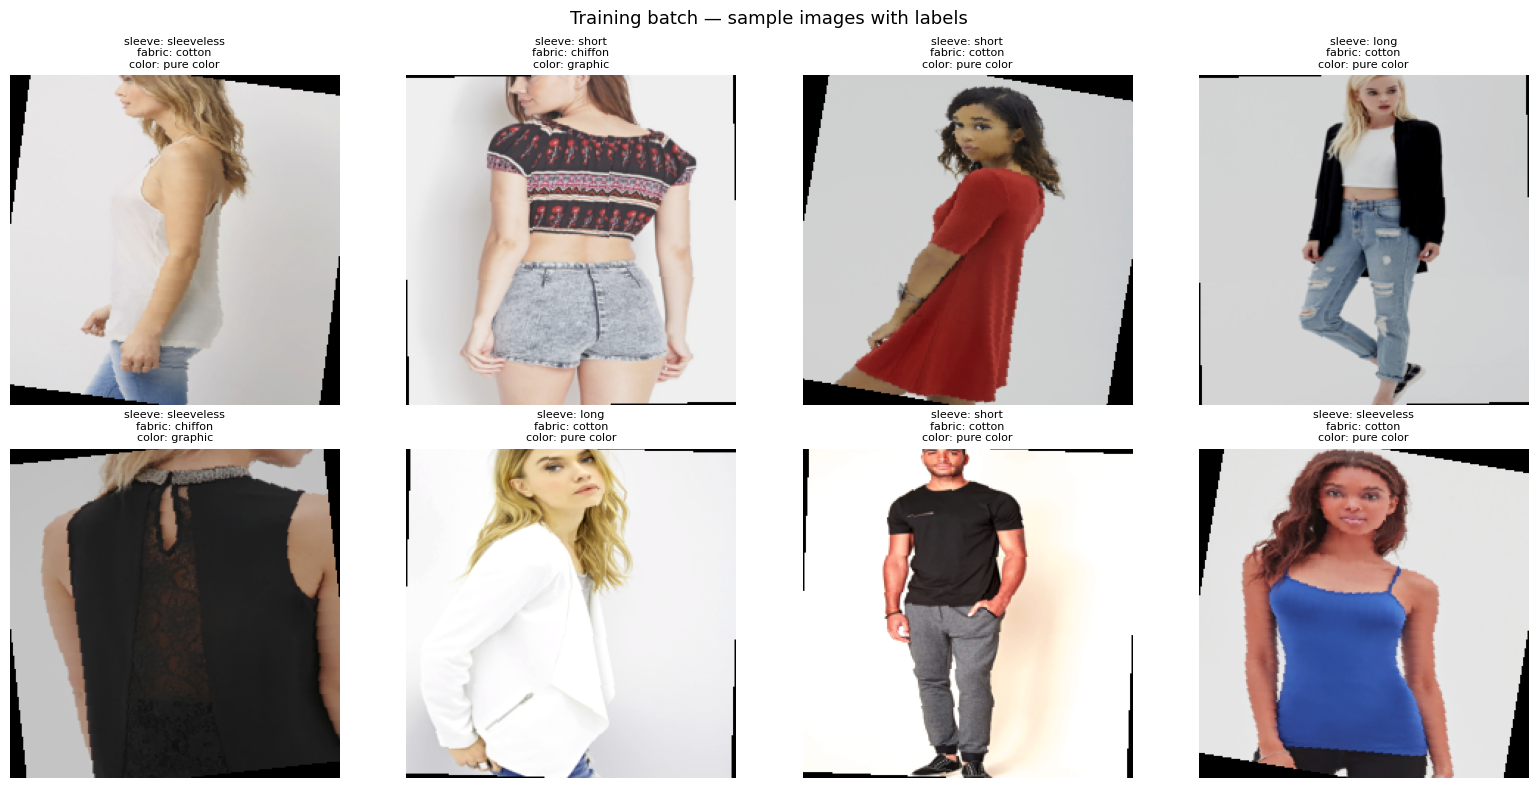

Plot saved to /kaggle/working/batch_samples.png


In [21]:
# Shows 8 images with their three labels decoded to human-readable strings.

def denormalise(tensor: torch.Tensor,
                mean=IMAGENET_MEAN, std=IMAGENET_STD) -> np.ndarray:
    """Reverse ImageNet normalisation for display purposes."""
    m = torch.tensor(mean).view(3, 1, 1)
    s = torch.tensor(std).view(3, 1, 1)
    img = tensor * s + m
    return img.permute(1, 2, 0).clamp(0, 1).numpy()


images, labels = next(iter(train_loader))
n_show = 8

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Training batch — sample images with labels", fontsize=13)

for i, ax in enumerate(axes.flat):
    ax.imshow(denormalise(images[i]))
    sl = SLEEVE_MAP[labels['sleeve_length'][i].item()]
    uf = FABRIC_MAP[labels['upper_fabric'][i].item()]
    uc = PATTERN_MAP[labels['upper_color'][i].item()]
    ax.set_title(f"sleeve: {sl}\nfabric: {uf}\ncolor: {uc}", fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "batch_samples.png", dpi=100, bbox_inches='tight')
plt.show()
print("Plot saved to", OUTPUT_DIR / "batch_samples.png")

# 18 — Summary and handoff to Notebook 03

In [22]:
# Everything the training notebook needs is now in /kaggle/working/

print("=" * 60)
print(" Notebook 02 — Data Preparation complete")
print("=" * 60)

print("\nFiles written to", OUTPUT_DIR)
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"  {f.name:30s}  {f.stat().st_size / 1024:>8.1f} KB")

print("""
Next steps (Notebook 03 — Training):
  1. Load train.csv / val.csv → GarmentDataset → DataLoaders
  2. Load class_weights.pt for weighted CrossEntropyLoss
  3. Instantiate EfficientNet-B0 with 3 classification heads
  4. Train with AdamW + cosine LR schedule
  5. Log per-head loss and accuracy at each epoch
""")

 Notebook 02 — Data Preparation complete

Files written to /kaggle/working
  .virtual_documents                   4.0 KB
  batch_samples.png                  730.5 KB
  class_distributions.png             69.2 KB
  class_weights.pt                     2.1 KB
  test.csv                           307.1 KB
  train.csv                         1432.4 KB
  val.csv                            306.4 KB

Next steps (Notebook 03 — Training):
  1. Load train.csv / val.csv → GarmentDataset → DataLoaders
  2. Load class_weights.pt for weighted CrossEntropyLoss
  3. Instantiate EfficientNet-B0 with 3 classification heads
  4. Train with AdamW + cosine LR schedule
  5. Log per-head loss and accuracy at each epoch

